##**CADI Deep Learning - Week 4 (Actividad 3)**
##**Aplicación de Técnicas de Optimización en una Red Neuronal (Colab + GitHub)**

## Descripción de la actividad
En esta actividad, las y los creadores de oportunidades aplicarán técnicas de optimización al
entrenamiento de una red neuronal en Google Colab, con el propósito de comprender cómo cambia el
proceso de aprendizaje cuando se ajusta la forma en que se actualizan los parámetros del modelo. La
optimización se evidencia en la evolución del entrenamiento (por ejemplo, comportamiento del loss y/o
métricas) y en la comparación de configuraciones.
La actividad se orienta a fortalecer criterio técnico sobre hiperparámetros de entrenamiento (como tasa
de aprendizaje) y sobre optimizadores (por ejemplo, variantes de descenso por gradiente),
manteniendo trazabilidad y evidencia reproducible en un notebook

##Características mínimas del notebook (obligatorias)
- Incluye una red neuronal entrenable (modelo base) y un proceso de entrenamiento por épocas/iteraciones.
- Evidencia aplicación de técnicas de optimización mediante comparación de al menos dos
configuraciones de entrenamiento (por ejemplo: dos optimizadores o dos tasas de aprendizaje), manteniendo constantes los demás elementos para que la comparación sea válida.
- Registra el comportamiento del entrenamiento (loss y/o métrica) para cada configuración, con evidencia visible (impresiones, tabla o gráfico).
- Reporta al menos una métrica de evaluación y una breve interpretación del resultado (qué mejoró, qué empeoró o qué fue más estable).
- Incluye análisis escrito (Markdown) con conclusiones breves sobre: (i) diferencias observadas entre configuraciones, (ii) estabilidad/velocidad de convergencia y (iii) principales hallazgos o dificultades.

# Semana 4 (Actividad 3) — Optimización en una Red Neuronal (versión Contact Center)

## Objetivo
Simular un **contact center** que aprende a **clasificar correctamente casos** (tipificación) a partir de ejemplos históricos.
Se comparan **dos estilos de "supervisión" (optimizadores)** manteniendo constante el resto:
- **Adam** (supervisión analítica basada en tendencias)
- **SGD** (supervisión tradicional con ajustes uniformes)

La evidencia se presenta con:
- Curvas de **loss** (reproceso/error) y **accuracy** (calidad)
- Métrica final sobre datos de prueba
- Conclusiones sobre convergencia, estabilidad y hallazgos

In [ ]:
## Importar librerías

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd


## Analogía con Contact Center (para entender el ejercicio)

- **Dataset (Fashion-MNIST)**: historial de casos ya resueltos.
- **Cada imagen**: un "caso" que llega al contact center.
- **Etiqueta (y)**: tipificación correcta del caso.
- **Modelo (red neuronal)**: el contact center que toma decisiones.
- **Entrenar**: capacitar al contact center con casos históricos.
- **Loss**: nivel de error/reproceso (cuando tipifica mal).
- **Accuracy**: KPI de calidad (porcentaje de casos bien clasificados).
- **Optimizador**: estilo de supervisión/corrección:
  - Adam: supervisión que aprende de patrones y corrige mejor.
  - SGD: supervisión con corrección más uniforme (puede ser más lenta).

In [ ]:
## Reproducibilidad
import random

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)


In [ ]:
##Cargar dataset (los “casos históricos”)

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

print("Train:", x_train.shape, y_train.shape)
print("Test :", x_test.shape, y_test.shape)


Train: (60000, 28, 28) (60000,)
Test : (10000, 28, 28) (10000,)


## Qué representa el dataset (como si fueran tipificaciones)

El dataset tiene 10 clases (10 tipificaciones posibles).
No son casos reales del contact center, pero sirven para simular el proceso de:

1) Recibir un "caso" (entrada)
2) Asignar una "tipificación" (predicción)
3) Comparar contra la tipificación correcta (verdad)
4) Medir el error (loss) y mejorar con ciclos (épocas)

Esto permite analizar claramente cómo la **optimización** impacta la velocidad y estabilidad del aprendizaje.

In [ ]:
##Normalizar datos

x_train = x_train / 255.0
x_test = x_test / 255.0


## Modelo base (estructura fija del Contact Center)

Para que la comparación sea válida, mantenemos constante:
- el mismo "contact center" (arquitectura del modelo),
- el mismo dataset,
- mismas épocas y batch_size.

Solo cambiaremos **la optimización** (optimizador / tasa de aprendizaje),
tal como exige la actividad.

Aquí se define un contact center entrenable, no es un modelo fijo.
El modelo se capacita por épocas, que equivalen a ciclos completos de revisión del histórico de PQRS, donde el sistema aprende y ajusta su forma de tipificar

In [ ]:
## Crear SIEMPRE el mismo modelo base / Incluye una red neuronal entrenable y un proceso de entrenamiento por épocas

def build_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),     # "leer" el caso
        tf.keras.layers.Dense(128, activation='relu'),     # análisis interno (equipo)
        tf.keras.layers.Dense(10, activation='softmax')    # decisión final (tipificación)
    ])
    return model



## Entrenamiento (capacitación)

Una **época** equivale a:
> Un ciclo completo donde el contact center revisa todos los casos históricos una vez.

Durante el entrenamiento medimos:
- **loss**: error/reproceso (cuando la tipificación sale mal)
- **accuracy**: porcentaje de casos bien clasificados (KPI de calidad)


In [ ]:
## Función para entrenar y evaluar
def train_and_evaluate(optimizer, config_name, epochs=10, batch_size=128):
    # Creamos un modelo nuevo (mismo contact center base)
    model = build_model()

    # Compilamos: definimos cómo se aprende (optimizador), cómo medimos error y calidad
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    print(f"\n===== Entrenando configuración: {config_name} =====")

    # Entrenamiento: el contact center aprende con casos históricos
    history = model.fit(
        x_train, y_train,
        validation_split=0.2,     # 20% se usa como "auditoría interna" durante el entrenamiento
        epochs=epochs,
        batch_size=batch_size,
        verbose=1
    )

    # Evaluación final: auditoría externa con casos que no vio durante el entrenamiento
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    print(f"Resultado FINAL en test -> Loss: {test_loss:.4f}, Accuracy: {test_acc:.4f}")

    return history, (test_loss, test_acc)

## Configuraciones a comparar (solo cambia optimización)

1) **Adam (lr=0.001)**: Supervisión analítica (aprende de patrones del historial).
2) **SGD (lr=0.001)**: Supervisión tradicional (correcciones más uniformes).

**IMPORTANTE:** Todo lo demás se mantiene igual (misma red, datos, épocas, batch_size)
para que la comparación sea válida.

Se compara el mismo contact center, con los mismos casos, durante el mismo número de ciclos, pero con dos estilos distintos de supervisión: uno más analítico (Adam) y otro más tradicional (SGD).
Esto garantiza que la diferencia observada se debe únicamente a la técnica de optimización.

In [ ]:
## Definir optimizadores

opt_adam = tf.keras.optimizers.Adam(learning_rate=0.001)
opt_sgd  = tf.keras.optimizers.SGD(learning_rate=0.001)


In [ ]:
##Entrenar ambas configuraciones

hist_adam, res_adam = train_and_evaluate(opt_adam, "Adam lr=0.001", epochs=10, batch_size=128)
hist_sgd,  res_sgd  = train_and_evaluate(opt_sgd,  "SGD lr=0.001",  epochs=10, batch_size=128)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



===== Entrenando configuración: Adam lr=0.001 =====
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8038 - loss: 0.5733 - val_accuracy: 0.8457 - val_loss: 0.4429
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8538 - loss: 0.4162 - val_accuracy: 0.8582 - val_loss: 0.4054
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8675 - loss: 0.3748 - val_accuracy: 0.8662 - val_loss: 0.3786
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8759 - loss: 0.3483 - val_accuracy: 0.8709 - val_loss: 0.3648
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8825 - loss: 0.3284 - val_accuracy: 0.8740 - val_loss: 0.3564
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8874 - loss: 0.3127 - val_accuracy: 0.8781 - val_loss: 0.3457
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8927 - loss: 0.2991 - val_accuracy: 0.8778 - val_loss: 0.3432
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/ste

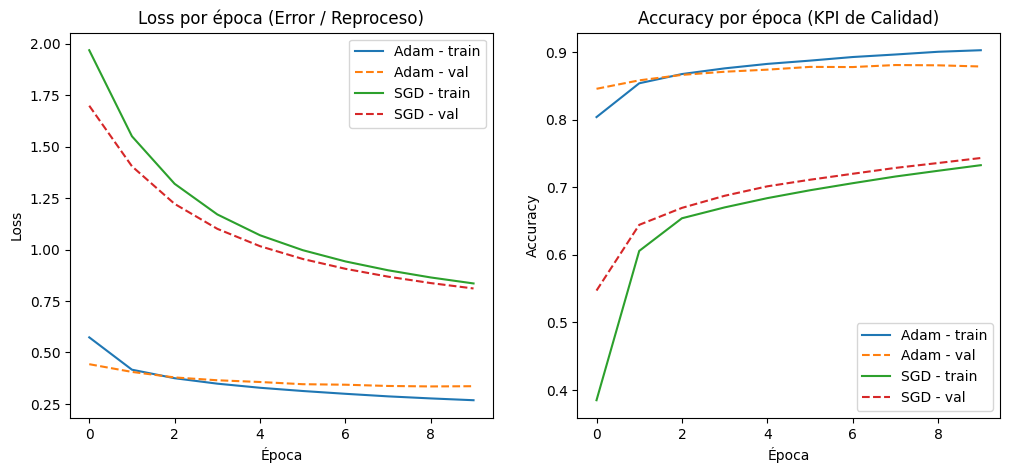

In [ ]:
##Graficar evidencia (loss y accuracy)

def plot_histories(histories, titles):
    plt.figure(figsize=(12,5))

    # LOSS (error/reproceso)
    plt.subplot(1,2,1)
    for h, t in zip(histories, titles):
        plt.plot(h.history['loss'], label=f'{t} - train')
        plt.plot(h.history['val_loss'], linestyle='--', label=f'{t} - val')
    plt.title("Loss por época (Error / Reproceso)")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()

    # ACCURACY (calidad)
    plt.subplot(1,2,2)
    for h, t in zip(histories, titles):
        plt.plot(h.history['accuracy'], label=f'{t} - train')
        plt.plot(h.history['val_accuracy'], linestyle='--', label=f'{t} - val')
    plt.title("Accuracy por época (KPI de Calidad)")
    plt.xlabel("Época")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.show()

plot_histories([hist_adam, hist_sgd], ["Adam", "SGD"])

In [ ]:
##Tabla resumen final (métrica de evaluación)
df_results = pd.DataFrame({
    "Configuración": ["Adam lr=0.001", "SGD lr=0.001"],
    "Test Loss (Error/Reproceso)": [res_adam[0], res_sgd[0]],
    "Test Accuracy (Calidad)": [res_adam[1], res_sgd[1]]
})

df_results

,Configuración,Test Loss (Error/Reproceso),Test Accuracy (Calidad)
0,Adam lr=0.001,0.358625,0.8712
1,SGD lr=0.001,0.833626,0.7259


## Interpretación de resultados (en términos de Contact Center)

- **Loss (Error/Reproceso):**
  Si el loss baja más rápido, significa que el "contact center" está cometiendo menos errores y necesita menos retrabajo.

- **Accuracy (Calidad):**
  Si la accuracy sube más rápido y se mantiene estable, significa que el modelo clasifica correctamente más casos.

En la comparación:
- Si **Adam** converge más rápido, sería como una supervisión que detecta patrones y corrige con más precisión.
- Si **SGD** es más lento o inestable, sería como una supervisión tradicional que requiere más ciclos para afinar criterios.
``

### Conclusiones (Semana 4 - Optimización aplicada a Tipificación PQRS)

### (i) Diferencias observadas entre configuraciones
- Manteniendo constante el mismo "contact center" (arquitectura) y los mismos casos,
  la diferencia se explica por el estilo de corrección (optimizador).
- Se evidencian diferencias en rapidez para reducir error (loss) y mejorar la calidad (accuracy).

### (ii) Estabilidad / velocidad de convergencia
- La velocidad de convergencia se observa en qué tan rápido baja el loss y sube la accuracy.
- La estabilidad se observa en qué tan suaves y consistentes son las curvas en el tiempo.

### (iii) Principales hallazgos o dificultades
- Mantener todo constante fue clave para que la comparación fuera justa (misma operación).
- La tasa de aprendizaje (learning rate) influye: valores altos pueden producir oscilación;
  valores bajos pueden hacer el aprendizaje demasiado lento.
- La lectura de métricas permite concluir cuál enfoque de optimización sería más conveniente
  para mejorar la tipificación y reducir reprocesos.

  
En general, el principal hallazgo fue que el estilo de optimización impacta significativamente
la velocidad y estabilidad del aprendizaje, incluso manteniendo la misma arquitectura y datos,
lo cual es clave al diseñar procesos de mejora en tipificación
